<a href="https://colab.research.google.com/github/sidms24/AML/blob/main/notebooks/VAE_hp_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# if we're on Colab, clone the repo so we have all source files
import os
if os.path.exists('AML'):
    !rm -rf AML
!git clone https://github.com/sidms24/AML.git
import sys
sys.path.append('AML')
!pip install -q -r AML/requirements.txt

Cloning into 'AML'...
remote: Enumerating objects: 581, done.
remote: Counting objects: 100% (127/127), done.
remote: Compressing objects: 100% (123/123), done.
remote: Total 581 (delta 80), reused 4 (delta 4), pack-reused 454 (from 2)
Receiving objects: 100% (581/581), 22.48 MiB | 36.95 MiB/s, done.
Resolving deltas: 100% (350/350), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.7/199.7 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.1/182.1 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 14.3 MB/s eta 0:00:00


In [2]:
import torch, numpy as np, pandas as pd
import optuna
from optuna.visualization.matplotlib import (
    plot_optimization_history, plot_param_importances,
    plot_slice, plot_contour
)
from optuna.distributions import CategoricalDistribution, FloatDistribution
from optuna.importance import get_param_importances
from copy import deepcopy
import math
import gc
optuna.logging.set_verbosity(optuna.logging.ERROR)
import tqdm
import tqdm.auto
tqdm.auto.tqdm = tqdm.tqdm
import joblib, warnings, os
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
from scipy.stats import rankdata
from utils.dataloader import load_data, _collate_mixed
from utils.encoders import dna_one_hot
from utils.param_sweep import run_vae_sweep, run_tvae_sweep
from utils.drift import compute_drift_scores
from utils.inference import extract_latents
from utils.loss import VAE_Loss
from utils.train import VAE_train
from models.vae import VAE
from utils.sweep_config import VAE_FIXED
from scipy.stats import spearmanr, rankdata
import matplotlib.pyplot as plt

from datasets import load_dataset
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True

os.makedirs('results', exist_ok=True)

Device: cuda


In [8]:
!wget -q https://huggingface.co/datasets/sidms/AML/resolve/main/sweep_results/optuna_study_vae.pkl -O optuna_study_vae.pkl
!wget -q https://huggingface.co/datasets/sidms/AML/resolve/main/sweep_results/optuna_study_vae2.pkl -O optuna_study_vae2.pkl

In [9]:
s1 = joblib.load("optuna_study_vae.pkl")
s2 = joblib.load("optuna_study_vae2.pkl")


unified_dists = {
    'latent_dim': CategoricalDistribution(choices=(8, 16, 32, 64, 128)),
    'beta': FloatDistribution(low=0.01, high=5.0, log=True),
    'hidden_dim': CategoricalDistribution(choices=(16, 32, 64, 128)),
}

merged = optuna.create_study(directions=s1.directions, study_name="merged")

for t in s1.trials + s2.trials:
    if not all(math.isfinite(v) for v in t.values):
        continue
    merged.add_trial(
      optuna.trial.create_trial(
          params=t.params,
          distributions=unified_dists,
          values=t.values,
          state=t.state,
          user_attrs=t.user_attrs,
    )
)


print(get_param_importances(merged, target=lambda t: t.values[0]))

joblib.dump(merged, "results/optuna_study_vae_merged.pkl")

{'hidden_dim': np.float64(0.9768854053943326), 'latent_dim': np.float64(0.022812400969664703), 'beta': np.float64(0.0003021936360027076)}


['results/optuna_study_vae_merged.pkl']

In [ ]:
# filter out diverged trials
rows = []
for t in merged.trials:
    if t.values[0] == float('inf'):
        continue
    rows.append({
        'trial': t.number,
        'latent_dim': t.params['latent_dim'],
        'beta': round(t.params['beta'], 3),
        'hidden_dim': t.params['hidden_dim'],
        'test_recon': round(t.values[0], 4),
        'silhouette': round(-t.values[1], 4),
        'test_kl': round(t.user_attrs['test_kl'], 4),
        'kl_collapsed': t.user_attrs['kl_collapsed'],
        'epochs': t.user_attrs['epochs_trained'],
        'test_loss':  round(t.params['beta'], 3) * t.user_attrs['test_kl'] + t.values[0],

    })
df_vae = pd.DataFrame(rows).sort_values('test_loss')
df_vae.to_csv('results/vae_results.csv', index=False)
df_vae

In [12]:
capped = optuna.create_study(directions=merged.directions, study_name="capped")
for t in merged.trials:
    loss = t.params['beta'] * t.user_attrs['test_kl'] + t.values[0]
    if math.isfinite(loss) and loss < 500:
        capped.add_trial(optuna.trial.create_trial(
            params=t.params, distributions=unified_dists,
            values=t.values, state=t.state, user_attrs=t.user_attrs,
        ))
print(len(capped.trials))

125


In [ ]:
print(f'Pareto front: {len(merged.best_trials)} trials')
for t in merged.best_trials:
    print(f"  #{t.number}: latent_dim={t.params['latent_dim']}, "
          f"beta={t.params['beta']:.3f}, recon={t.values[0]:.4f}, "
          f"sil={-t.values[1]:.4f}, "
          f"hidden_dim={t.params['hidden_dim']}, "
          f"total_loss={round(t.params['beta'], 3) * t.user_attrs['test_kl'] + t.values[0]:.4f}")

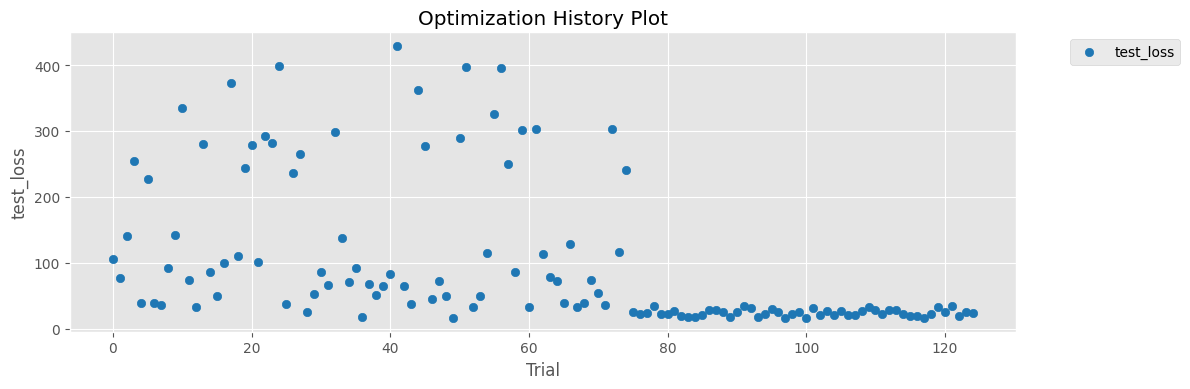

In [14]:
plot_optimization_history(capped, target=lambda t:  round(t.params['beta'], 3) * t.user_attrs['test_kl'] + t.values[0] ,
                          target_name='test_loss')
fig = plt.gcf()
fig.set_size_inches(12, 4)
plt.savefig('results/vae_history.png', dpi=150, bbox_inches='tight')

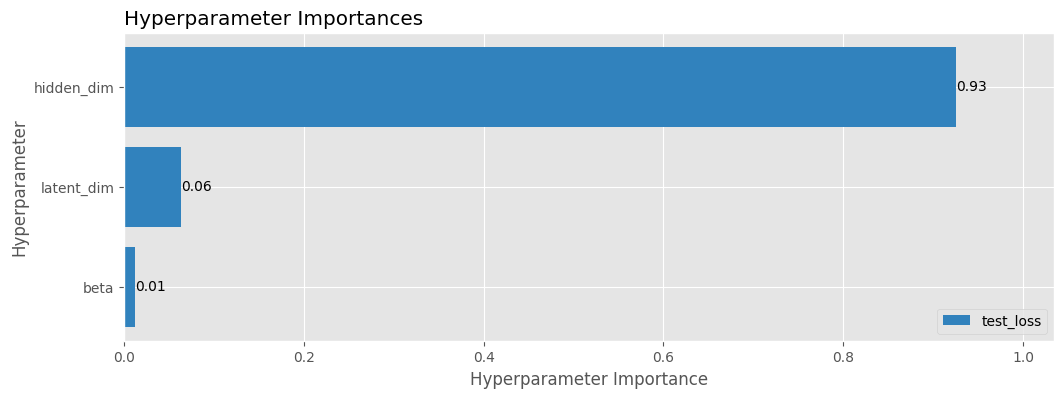

In [15]:
plot_param_importances(capped, target=lambda t: round(t.params['beta'], 3) * t.user_attrs['test_kl'] + t.values[0], target_name='test_loss')
fig = plt.gcf()
fig.set_size_inches(12, 4)
plt.savefig('results/vae_param_importances.png', dpi=150, bbox_inches='tight')

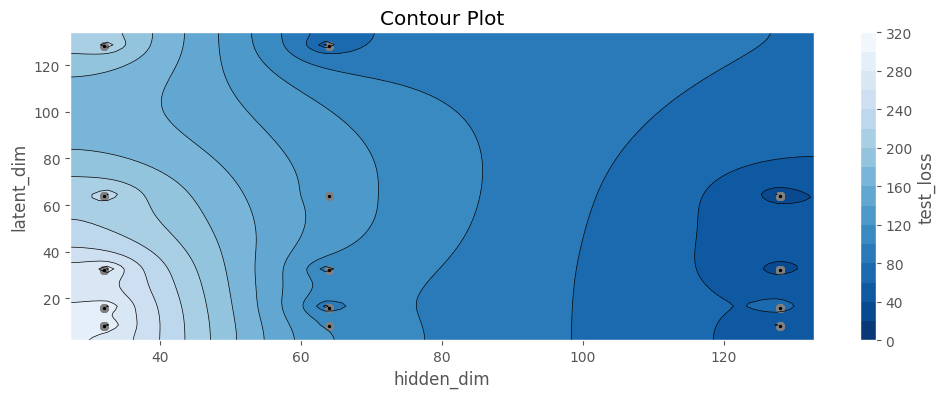

In [16]:
plot_contour(capped, params=['hidden_dim', 'latent_dim'],
             target=lambda t: round(t.params['beta'], 3) * t.user_attrs['test_kl'] + t.values[0], target_name='test_loss')
fig = plt.gcf()
fig.set_size_inches(12, 4)
plt.savefig('results/vae_contour.png', dpi=150, bbox_inches='tight')

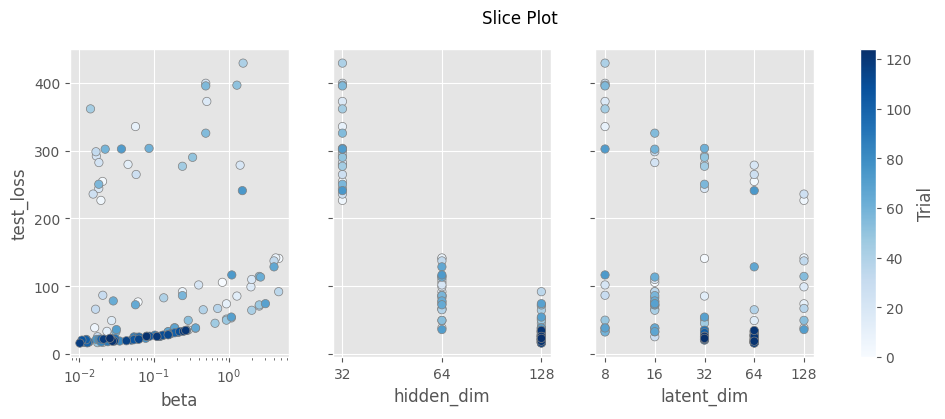

In [17]:
plot_slice(capped, params=['latent_dim', 'beta', 'hidden_dim'],
           target=lambda t:round(t.params['beta'], 3) * t.user_attrs['test_kl'] + t.values[0], target_name='test_loss')
fig = plt.gcf()
fig.set_size_inches(12, 4)
plt.savefig('results/vae_slice.png', dpi=150, bbox_inches='tight')

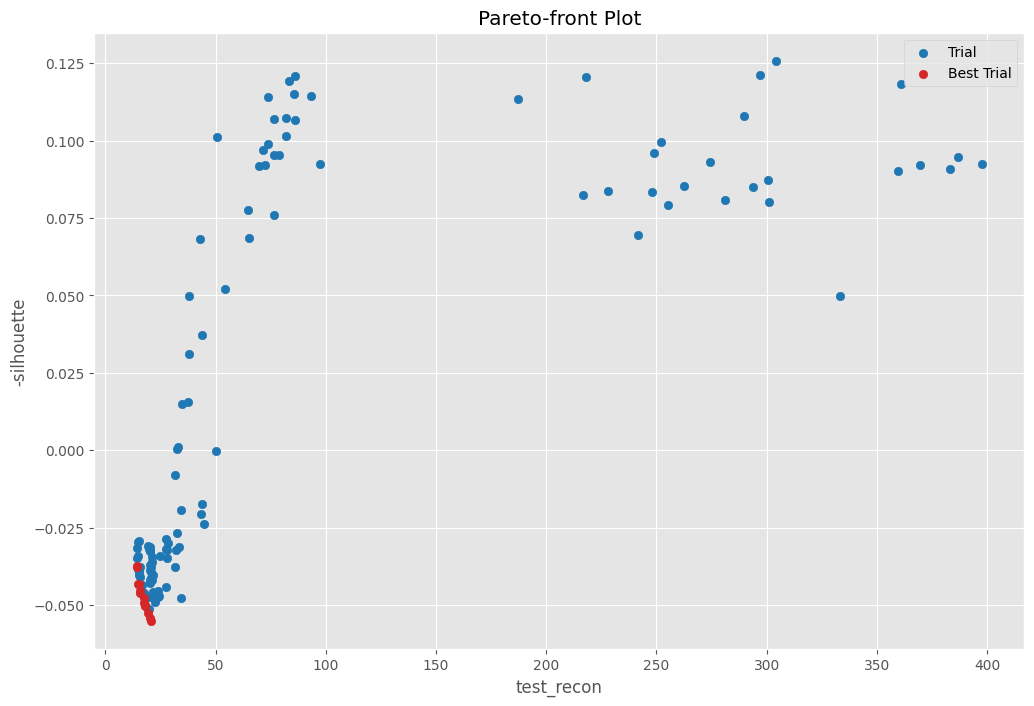

In [32]:
from optuna.visualization.matplotlib import plot_pareto_front
plot_pareto_front(capped, target_names=['test_recon', '-silhouette'])
fig = plt.gcf()
fig.set_size_inches(12, 8)
plt.savefig('results/vae_pareto.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
pareto = merged.best_trials
for t in sorted(pareto,  key=lambda t:round(t.params['beta'], 3) * t.user_attrs['test_kl'] + t.values[0]):
    print(f"Trial {t.number}: recon={t.values[0]:.1f}, "
          f"sil={-t.values[1]:.4f}, beta={t.params['beta']:.4f}, "
          f"latent={t.params.get('latent_dim')}, hidden={t.params.get('hidden_dim')}")

Trial 69: recon=14.1, sil=0.0374, beta=0.0176, latent=64, hidden=128
Trial 50: recon=14.4, sil=0.0378, beta=0.0209, latent=64, hidden=128
Trial 107: recon=15.0, sil=0.0431, beta=0.0348, latent=64, hidden=128
Trial 141: recon=14.8, sil=0.0431, beta=0.0427, latent=64, hidden=128
Trial 139: recon=15.6, sil=0.0456, beta=0.0626, latent=64, hidden=128
Trial 105: recon=15.8, sil=0.0462, beta=0.0596, latent=64, hidden=128
Trial 145: recon=17.3, sil=0.0478, beta=0.1093, latent=64, hidden=128
Trial 128: recon=18.0, sil=0.0504, beta=0.1196, latent=64, hidden=128
Trial 130: recon=17.5, sil=0.0492, beta=0.1330, latent=64, hidden=128
Trial 138: recon=17.8, sil=0.0500, beta=0.1539, latent=64, hidden=128
Trial 111: recon=19.1, sil=0.0525, beta=0.1564, latent=64, hidden=128
Trial 134: recon=20.0, sil=0.0542, beta=0.2191, latent=64, hidden=128
Trial 146: recon=20.9, sil=0.0551, beta=0.2640, latent=64, hidden=128


In [ ]:
# best vs worst by total loss — used for the ablation study below
valid_trials = [t for t in merged.trials if t.values[0] != float('inf')]
sorted_by_tLoss = sorted(valid_trials, key=lambda t:round(t.params['beta'], 3) * t.user_attrs['test_kl'] + t.values[0] )
best_trial = sorted_by_tLoss[0]
worst_trial = sorted_by_tLoss[-1]

configs = {
    'best':  {'latent_dim': best_trial.params['latent_dim'],
              'beta': best_trial.params['beta'], 'hidden_dim':best_trial.params['hidden_dim'],
             },
    'worst': {'latent_dim': worst_trial.params['latent_dim'],
              'beta': worst_trial.params['beta'], 'hidden_dim':worst_trial.params['hidden_dim'],
             },
}
print('Best config: ', configs['best'])
print('Worst config:', configs['worst'])

In [34]:
# we use H1N1_global for the ablation — same dataset as the main training notebook
h1n1_data = load_data(subtype='H1N1_global', encoder=dna_one_hot, batch_size=512)
h1n1_train, h1n1_test = h1n1_data()

sample_x, _ = next(iter(h1n1_train))
INPUT_DIM = sample_x.shape[1]
SEQ_LENGTH = sample_x.shape[2]
print(f'H1N1 — input_dim={INPUT_DIM}, seq_length={SEQ_LENGTH}, '
      f'train batches={len(h1n1_train)}, test batches={len(h1n1_test)}')

Map (num_proc=4): 100%|██████████| 6245/6245 [00:01<00:00, 4411.42 examples/s]


H1N1 — input_dim=5, seq_length=1759, train batches=49, test batches=13


In [35]:
drift_models = {}
for label, cfg in configs.items():
    print(f'\nTraining {label}: latent_dim={cfg["latent_dim"]}, beta={cfg["beta"]:.3f}')
    torch.manual_seed(42)
    model = VAE(INPUT_DIM, cfg['hidden_dim'], cfg['latent_dim'], SEQ_LENGTH).to(device)
    criterion = VAE_Loss(beta=cfg['beta'])
    optimiser = torch.optim.Adam(model.parameters(), lr=3e-5)
    model, history = VAE_train(
        model, h1n1_train, h1n1_test,
        criterion, optimiser, device,
        epochs=80, patience=10, anneal_epochs=10, save_every=50,
    )

    drift_models[label] = model  # move to CPU after training
    del criterion, optimiser
    gc.collect()
    torch.cuda.empty_cache()
    print(f'  Final test loss: {history["test_tloss"][-1]:.4f}')


Training best: latent_dim=64, beta=0.010


Training:  62%|██████▎   | 50/80 [02:18<01:05,  2.17s/epoch, avg loss=12.1535]

  Checkpoint saved at epoch 50 -> checkpoint.pt


Training: 100%|██████████| 80/80 [03:20<00:00,  2.51s/epoch, avg loss=7.3122]


  Final test loss: 10.0338

Training worst: latent_dim=8, beta=0.076


Training:  62%|██████▎   | 50/80 [01:33<00:46,  1.56s/epoch, avg loss=958.6964]

  Checkpoint saved at epoch 50 -> checkpoint.pt


Training: 100%|██████████| 80/80 [02:19<00:00,  1.75s/epoch, avg loss=595.1955]


  Final test loss: 589.8583


In [36]:
raw = load_dataset('sidms/AML', 'H1N1_drift')


encoder = dna_one_hot()
ds = raw['train'].map(encoder, batched=True, num_proc=4, remove_columns=['sequence'])
ds.set_format(type='torch', columns=['input_ids', 'year'], output_all_columns=True)

h1n1_drift = DataLoader(ds, batch_size=512, shuffle=False,
                         collate_fn=_collate_mixed, num_workers=4, pin_memory=True)


# load CDC hospitalisation data
season_summary = pd.read_csv('https://huggingface.co/datasets/sidms/AML/resolve/main/cdc_data/season_summary.csv')
hosp = season_summary[['season', 'hosp_rate_overall']].dropna(subset=['hosp_rate_overall'])
print(f'Hospitalisation data: {len(hosp)} seasons')
hosp.head()

Map (num_proc=4): 100%|██████████| 25760/25760 [00:05<00:00, 4847.12 examples/s]


Hospitalisation data: 17 seasons


,season,hosp_rate_overall
12,2009-10,29.3
13,2010-11,21.5
14,2011-12,8.7
15,2012-13,44.0
16,2013-14,35.1


In [ ]:
drift_results = {}
for label, model in drift_models.items():
    result = extract_latents(model, h1n1_drift, device=device)
    latents, years = result[0], result[1]
    months = result[3] if len(result) > 3 else None
    seasons = result[4] if len(result) > 4 else None
    drift_df = compute_drift_scores(latents, years, months=months,
                                    seasons=seasons, max_per_season = 30)
    drift_results[label] = drift_df

drift_results['best']

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, drift_df) in zip(axes, drift_results.items()):
    merged = drift_df.merge(hosp, on='season', how='inner')
    # COVID NPIs distort this season beyond recognition
    merged = merged[merged['season'] != '2020-21']

    rho, pval = spearmanr(merged['drift_norm'], merged['hosp_rate_overall'])

    ax.scatter(merged['drift_norm'], merged['hosp_rate_overall'], s=40, alpha=0.7)
    for _, row in merged.iterrows():
        ax.annotate(row['season'], (row['drift_norm'], row['hosp_rate_overall']),
                    fontsize=7, alpha=0.6)
    cfg = configs[label]
    ax.set_title(f"{label.title()} config (ld={cfg['latent_dim']}, β={cfg['beta']:.2f})\n"
                 f"Spearman ρ={rho:.3f}, p={pval:.3f}")
    ax.set_xlabel('Normalised drift score')
    ax.set_ylabel('Hospitalisation rate (per 100k)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/drift_sensitivity_best_vs_worst.png', dpi=150, bbox_inches='tight')
plt.show()

In [44]:
from huggingface_hub import upload_folder

upload_folder(
    folder_path="results",
    repo_id="sidms/AML",
    repo_type="dataset",
    path_in_repo = "sweep_results/full_hp_analysis"
)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            
New Data Upload               : |          |  0.00B /  0.00B            

  ...itivity_best_vs_worst.png: 100%|██████████| 94.1kB / 94.1kB            


  ...tuna_study_vae_merged.pkl: 100%|██████████| 41.4kB / 41.4kB            



  ...t/results/vae_contour.png: 100%|██████████|  112kB /  112kB            




  ...t/results/vae_history.png: 100%|██████████| 48.8kB / 48.8kB            





  ...vae_param_importances.png: 100%|██████████| 41.0kB / 41.0kB            






  ...nt/results/vae_pareto.png: 100%|██████████| 65.3kB / 65.3kB            







  ...ent/results/vae_slice.png: 100%|██████████|  101kB /  101kB            

  ...itivity_best_vs_worst.png: 100%|██████████| 94.1kB / 94.1kB            


  ...tuna_study_vae_merged.pkl: 100%|██████████| 41.4kB / 41.4kB            



  ...t/results/vae_contour.png: 100%|██████████|  112kB /  112kB            




  ...t/results/vae_history.png: 100%|█████████

CommitInfo(commit_url='https://huggingface.co/datasets/sidms/AML/commit/1f35d925dcfd677857640c45d1de5da3c8985c25', commit_message='Upload folder using huggingface_hub', commit_description='', oid='1f35d925dcfd677857640c45d1de5da3c8985c25', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/sidms/AML', endpoint='https://huggingface.co', repo_type='dataset', repo_id='sidms/AML'), pr_revision=None, pr_num=None)